# California Housing Market Analysis: A Zillow Data Exploration
An investigation into home value trends across California, with a deep dive into the Los Banos commuter market (2021 – 2026).

### I. Data Acquisition and Initial Processing
Setting up the environment and filtering the raw Zillow dataset for California-specific data.

In [35]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

housing_df = pd.read_csv("city_homevalue_zillow.csv")

#Initial look country wide
housing_df.head()

# Create a new dataframe containing only California cities
ca_housing = housing_df[housing_df['State'] == 'CA'].copy()

# Print the shape to see how many CA cities we are working with
print(f"Number of CA cities in dataset: {ca_housing.shape[0]}")


Number of CA cities in dataset: 960


### II. Temporal Filtering (2021 – 2026)
Narrowing the analysis to the last five years to capture the post-COVID housing surge and recent market shifts.

In [36]:
# Identify all date columns
all_dates = [col for col in ca_housing.columns if col.startswith(('19', '20'))]

# Filter for dates from 2021 to 2026 (the end of your dataset)
recent_dates = [col for col in all_dates if col >= '2021-01-01']

# Keep the identifying info + the recent dates
cols_to_keep = ['RegionName', 'CountyName', 'SizeRank'] + recent_dates
ca_recent = ca_housing[cols_to_keep]

print(f"Dataframe now narrowed to {len(recent_dates)} months of data.")

Dataframe now narrowed to 63 months of data.


### III. Data Reshaping: Wide to Long Format
Restructuring the dataset into a tidy format suitable for time-series analysis and visualization.

In [50]:
# Melt the data so each row is a specific city on a specific date
ca_long = pd.melt(ca_recent, 
                  id_vars=['RegionName', 'CountyName', 'SizeRank'], 
                  value_vars=recent_dates, 
                  var_name='Date', 
                  value_name='HomeValue')

# Convert the 'Date' column to a format Python understands as time
ca_long['Date'] = pd.to_datetime(ca_long['Date'])
ca_long.head()

,RegionName,CountyName,SizeRank,Date,HomeValue
0,Los Angeles,Los Angeles County,1,2021-01-31,8.011900e+05
1,San Diego,San Diego County,8,2021-01-31,7.304865e+05
2,San Jose,Santa Clara County,11,2021-01-31,1.106885e+06
3,San Francisco,San Francisco County,17,2021-01-31,1.367259e+06
4,Sacramento,Sacramento County,28,2021-01-31,4.094195e+05


### IV. Visualizing Statewide Trends
Plotting the average home value across California to establish a baseline for regional comparisons.

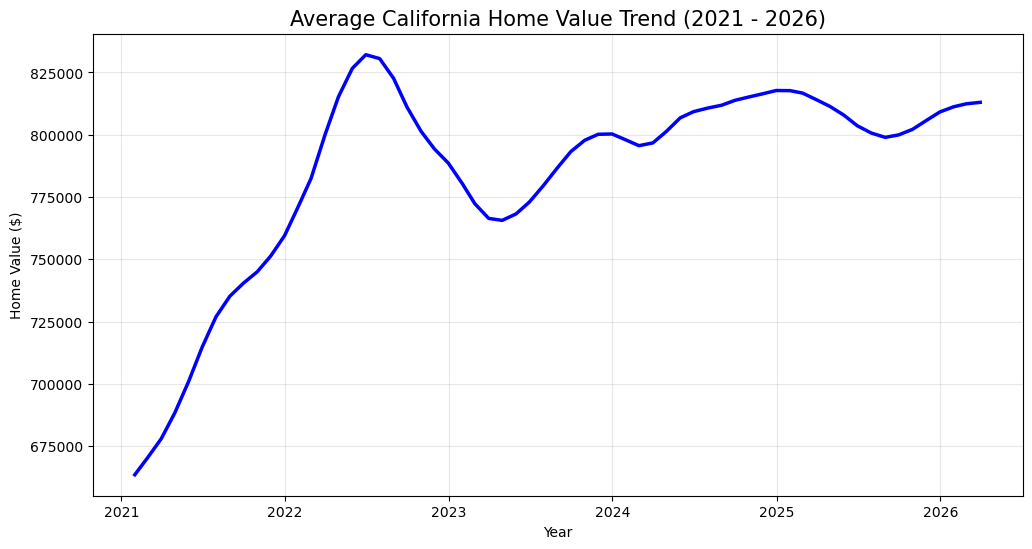

In [39]:
import matplotlib.pyplot as plt

# Group by Date to get the average home value for all CA cities combined
ca_trend = ca_long.groupby('Date')['HomeValue'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=ca_trend, x='Date', y='HomeValue', color='blue', linewidth=2.5)

plt.title('Average California Home Value Trend (2021 - 2026)', fontsize=15)
plt.ylabel('Home Value ($)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

### V. Local Case Study: Los Banos, CA
Sociological Context & Market Profile

The "Bay Area Pressure Valve": Los Banos serves as a vital commuter hub for Silicon Valley workers seeking relative affordability.

Rapid Urbanization: Significant population growth (from 36k in 2010 to ~49k in 2026) has transformed the city's economic landscape.

Demographic Shift: A young, diverse workforce contributes to high demand for single-family housing developments.

In [40]:
# Isolate Los Banos
los_banos_data = ca_recent[ca_recent['RegionName'] == 'Los Banos'].copy()

# A quick look at the raw row for the last few months
print("Latest 5 months of raw data for Los Banos:")
print(los_banos_data.iloc[:, -5:])

Latest 5 months of raw data for Los Banos:
        2025-11-30     2025-12-31     2026-01-31     2026-02-28     2026-03-31
1274  464135.17263  463727.401438  463270.828806  462823.580985  462222.533906


In [43]:
# Identify the date columns again
date_cols = [col for col in los_banos_data.columns if col.startswith(('19', '20'))]

# Melt the wide columns into long rows
lb_long = pd.melt(los_banos_data, 
                  id_vars=['RegionName', 'CountyName'], 
                  value_vars=date_cols, 
                  var_name='Date', 
                  value_name='HomeValue')

# Convert the Date column to a proper datetime format
lb_long['Date'] = pd.to_datetime(lb_long['Date'])

# Show the first few rows of the new format
lb_long.head(15)

,RegionName,CountyName,Date,HomeValue
0,Los Banos,Merced County,2021-01-31,378665.358138
1,Los Banos,Merced County,2021-02-28,385035.947367
2,Los Banos,Merced County,2021-03-31,392028.308209
3,Los Banos,Merced County,2021-04-30,399552.619343
4,Los Banos,Merced County,2021-05-31,407261.205246
5,Los Banos,Merced County,2021-06-30,414735.602315
6,Los Banos,Merced County,2021-07-31,421792.924060
7,Los Banos,Merced County,2021-08-31,428349.001437
8,Los Banos,Merced County,2021-09-30,434576.132222
9,Los Banos,Merced County,2021-10-31,440542.653125


### VI. Analyzing the Los Banos Trend Line
Isolating local data to identify how the "Pacheco Pass" commuter effect influences price volatility compared to state averages.

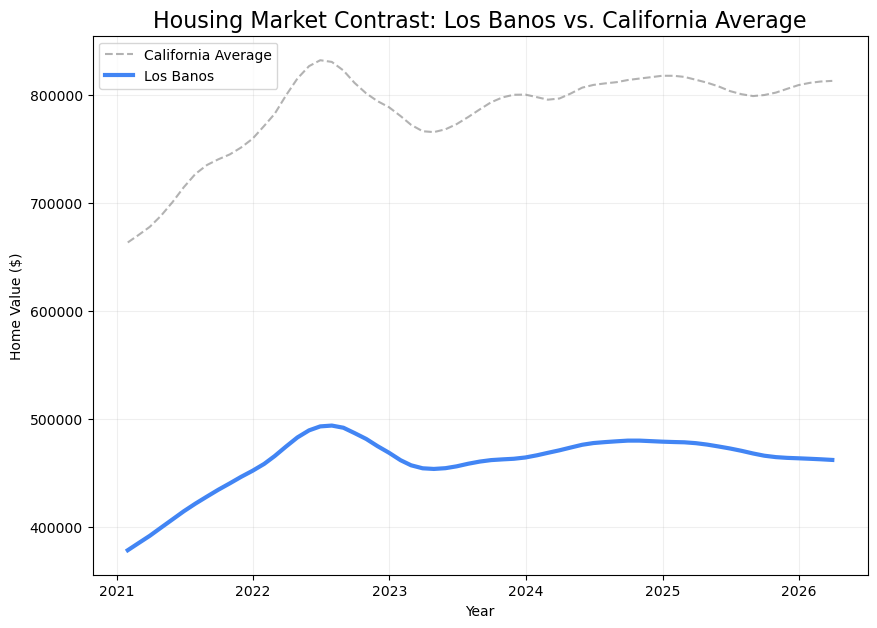

In [44]:
# 1. Calculate the CA state-wide average again (as a baseline)
ca_baseline = ca_long.groupby('Date')['HomeValue'].mean().reset_index()

# 2. Create the plot
plt.figure(figsize=(10, 7))

# Plot California State Average
sns.lineplot(data=ca_baseline, x='Date', y='HomeValue', 
             label='California Average', color='gray', linestyle='--', alpha=0.6)

# Plot Los Banos
sns.lineplot(data=lb_long, x='Date', y='HomeValue', 
             label='Los Banos', color='#4285F4', linewidth=3)

plt.title('Housing Market Contrast: Los Banos vs. California Average', fontsize=16)
plt.ylabel('Home Value ($)')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### VII. Measuring Momentum: Market Reset or Structural Crash?
Analyzing the velocity of price changes to determine if the current decline is a controlled "reset" or a structural "crash."

In [48]:
# 1. Calculate the percentage change month-to-month
lb_long['PctChange'] = lb_long['HomeValue'].pct_change() * 100

# 2. Look at the last 12 months to see the current trend speed
print("Los Banos Monthly Price Change (%) - Last 12 Months:")
print(lb_long[['Date', 'HomeValue', 'PctChange']].tail(12))

# 3. Calculate the average monthly decline in the last year
last_year_decline = lb_long[lb_long['Date'] >= '2025-05-01']['PctChange'].mean()
print(f"\nAverage monthly change over the last year: {last_year_decline:.2f}%")

Los Banos Monthly Price Change (%) - Last 12 Months:
         Date      HomeValue  PctChange
51 2025-04-30  476422.480203  -0.274002
52 2025-05-31  474658.342595  -0.370288
53 2025-06-30  472833.143469  -0.384529
54 2025-07-31  470659.901301  -0.459621
55 2025-08-31  468195.683286  -0.523567
56 2025-09-30  466130.736991  -0.441043
57 2025-10-31  464822.547880  -0.280649
58 2025-11-30  464135.172630  -0.147879
59 2025-12-31  463727.401438  -0.087856
60 2026-01-31  463270.828806  -0.098457
61 2026-02-28  462823.580985  -0.096541
62 2026-03-31  462222.533906  -0.129865

Average monthly change over the last year: -0.27%


### VIII. The Rhythms of the Central Valley: Seasonal Patterns
Exploring the historical "Spring Surge" typical of family-oriented commuter markets, where relocation cycles are tied to school calendars and weather.

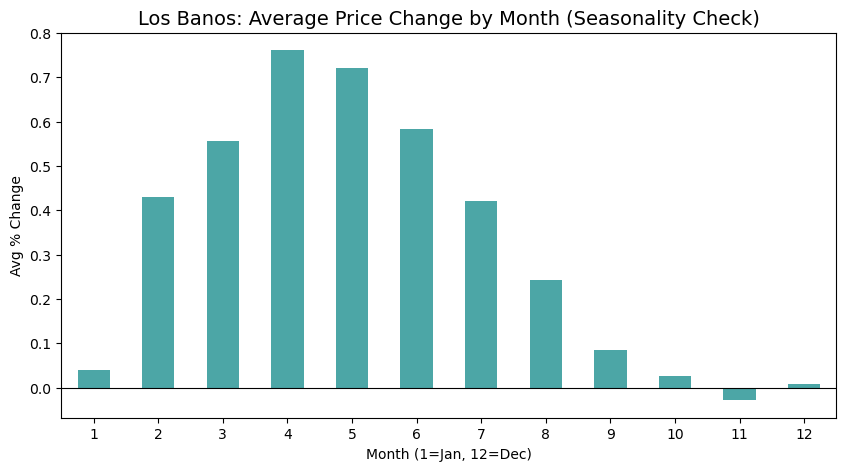

In [46]:
# 1. Create a 'Month' column (1 = Jan, 12 = Dec)
lb_long['Month'] = lb_long['Date'].dt.month

# 2. Calculate the average percent change for each month across all years
monthly_seasonality = lb_long.groupby('Month')['PctChange'].mean()

# 3. Visualize it
plt.figure(figsize=(10, 5))
monthly_seasonality.plot(kind='bar', color='teal', alpha=0.7)

plt.title('Los Banos: Average Price Change by Month (Seasonality Check)', fontsize=14)
plt.ylabel('Avg % Change')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.show()

### IX. Divergence Analysis: The 2026 Spring Surge Failure
A direct comparison of 2026 performance against historical norms to identify where and why the market has decoupled from its traditional growth cycle.

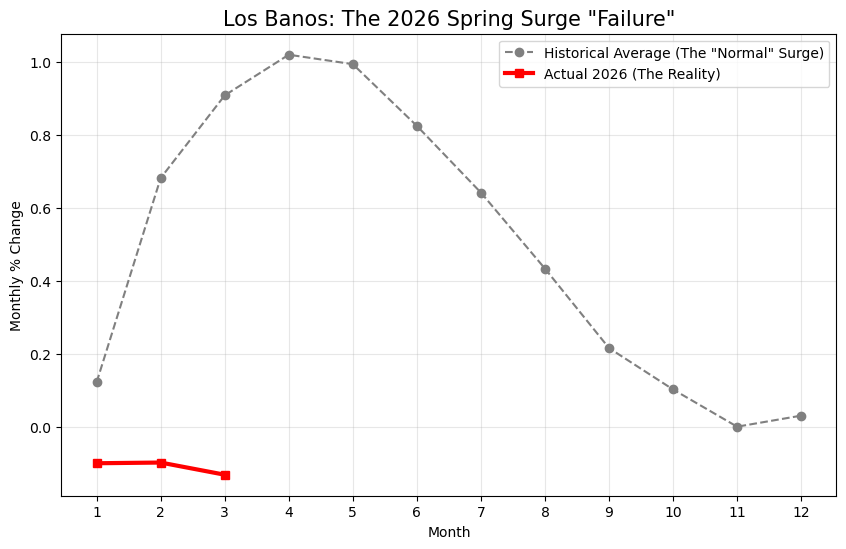

In [47]:
# 1. Create the Historical Average Baseline (Month 1 - 12)
historical_avg = lb_long[lb_long['Date'] < '2025-01-01'].groupby('Month')['PctChange'].mean()

# 2. Extract the 2026 performance so far (Jan, Feb, March)
current_year = lb_long[lb_long['Date'] >= '2026-01-01'].copy()
current_year['Month'] = current_year['Date'].dt.month
current_2026 = current_year.groupby('Month')['PctChange'].mean()

# 3. Plot them together
plt.figure(figsize=(10, 6))
plt.plot(historical_avg.index, historical_avg.values, label='Historical Average (The "Normal" Surge)', 
         color='gray', linestyle='--', marker='o')
plt.plot(current_2026.index, current_2026.values, label='Actual 2026 (The Reality)', 
         color='red', linewidth=3, marker='s')

plt.title('Los Banos: The 2026 Spring Surge "Failure"', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Monthly % Change')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### X. Conclusion: The "Commuter Ceiling" and Market Stability
Final analysis of the Los Banos housing trajectory. The data suggests that while historical surges provided a safety net for values, 2026 represents a fundamental shift in buyer behavior and economic capability.

### Key Takeaways:

Stagnation vs. Freefall: The average monthly decline of -0.27% points toward a stabilization rather than a collapse.

Structural Dominance: Higher interest rates and regional economic shifts are currently overriding traditional seasonal growth.

The "Wait-and-See" Market: Both buyers and sellers have reached an equilibrium of caution, resulting in the "Surge Failure" observed in early 2026.

Will the months of October to December see a bigger dip this year?